# 02 · EDA orientado a riesgo — Caso 15 · Caja Rural 360

**Alcance:** sección **6.4** del Trabajo Integrador Final. El EDA no describe variables: responde preguntas de riesgo y de negocio, y cada hallazgo termina en una consecuencia para la política o el modelo. La narrativa está en `reports/04_eda_orientado_a_riesgo.md`.

**Regla de uso de muestras** (coherente con 6.2 y 6.3). Las relaciones variable-riesgo se miden en **DEV (2021-2023)**. **VAL (2024)** se muestra para ver si cada hallazgo se sostiene fuera de DEV, sin decidir con ella. La cosecha **OOT (2025) no se abre variable por variable**: queda reservada para la evaluación final. Todas las tasas llevan intervalo de confianza (Wilson) y las comparaciones múltiples se corrigen (Benjamini-Hochberg).

| Sección | Pregunta de riesgo |
|---|---|
| 1 | ¿Cuántas variables tienen señal real y cuántas son ruido? |
| 2 | ¿Qué tan fuerte y estable es el buró? |
| 3 | El default subió: ¿cambió el nivel de riesgo o la capacidad de ordenar? ¿Fue un salto o una tendencia? |
| 4 | ¿Cómo pesa la capacidad de pago y cómo se combina con el buró? |
| 5 | ¿El historial de mora y las consultas agregan riesgo? |
| 6 | ¿Crecer por canales digitales y con clientes nuevos aumenta el riesgo? |
| 7 | ¿Informalidad, territorio, hogar o edad cambian el riesgo? (fairness) |
| 8 | ¿Monto y plazo cambian la PD? ¿Dónde se concentra la exposición? |
| 9 | ¿La pérdida creció por frecuencia o por severidad? |
| 10 | Mapa de segmentos: ¿dónde se concentra la pérdida? |
| 11 | Hallazgos accionables |

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import config as cfg, data, eda, features, validation

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
for d in (cfg.FIGURES, cfg.TABLES):
    d.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.grid": True, "grid.color": GRID, "grid.linestyle": "-",
    "grid.linewidth": 0.6, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9.5, "legend.frameon": False, "figure.dpi": 100,
})

def savefig(fig, name):
    fig.savefig(cfg.FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")

def pct_axis(ax, axis="y", decimals=0):
    a = ax.yaxis if axis == "y" else ax.xaxis
    a.set_major_locator(plt.MaxNLocator(nbins=6, steps=[1, 2, 5, 10]))
    a.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.{decimals}%}"))

def barras_con_ic(ax, x, tasa, lo, hi, color, ancho=0.38, desplazamiento=0.0, etiqueta=None, valores=True):
    pos = np.arange(len(x)) + desplazamiento
    ax.bar(pos, tasa, width=ancho, color=color, label=etiqueta)
    ax.errorbar(pos, tasa, yerr=[np.asarray(tasa) - np.asarray(lo), np.asarray(hi) - np.asarray(tasa)],
                fmt="none", ecolor=INK_2, elinewidth=0.9, capsize=2)
    if valores:
        for p_, v in zip(pos, tasa):
            ax.text(p_, v, f"{v:.1%}", ha="center", va="bottom", fontsize=8, color=INK_2)
    return pos

print("Raíz del repositorio:", ROOT)

Raíz del repositorio: /home/claude/work/Proyecto_Final_Credit_Scoring-main


In [2]:
from scipy import stats

raw = data.load_raw()
pop, _ = data.pd_population(raw)
fx = features.build_features(pop)
T = cfg.TARGET
dev, val = fx[fx["sample"] == "DEV"].copy(), fx[fx["sample"] == "VAL"].copy()
muestras = {"DEV": dev, "VAL": val}
dv = pd.concat([dev, val])
ttd_dev = raw[raw[cfg.DATE_COL] <= cfg.TEMPORAL_SPLITS["DEV"][1]]

cats = ["region", "channel", "employment_type"]
cands = data.pd_candidate_features() + features.DERIVED_CANDIDATES
nums = [c for c in cands if c not in cats]
print(f"DEV: {len(dev):,} créditos, {int(dev[T].sum())} defaults ({dev[T].mean():.1%}) | VAL: {len(val):,}, {int(val[T].sum())} defaults ({val[T].mean():.1%})")
print(f"Candidatas evaluadas: {len(cands)} ({len(nums)} numéricas, {len(cats)} categóricas)")

DEV: 3,443 créditos, 351 defaults (10.2%) | VAL: 1,151, 161 defaults (14.0%)
Candidatas evaluadas: 22 (19 numéricas, 3 categóricas)


## 1. ¿Cuántas variables tienen señal real?

Con 22 candidatas, algunas saldrán "significativas" por azar. Se prueba cada una en DEV (Mann-Whitney para numéricas, chi-cuadrado para categóricas) y se corrige por comparaciones múltiples con **Benjamini-Hochberg** (q < 0.05).

,variable,tipo,auc_dev,p_dev,auc_val_info,misma_direccion_en_val,p_val_info,q_bh,senal_en_dev
0,bureau_score,numérica,0.3052,0.0000,0.3248,True,NaN,0.0000,True
1,dti,numérica,0.5712,0.0000,0.5320,True,NaN,0.0001,True
2,dti_post,numérica,0.5702,0.0000,0.5380,True,NaN,0.0001,True
3,prior_delinquencies_24m,numérica,0.5434,0.0025,0.4912,False,NaN,0.0135,True
4,monthly_debt_payment,numérica,0.5442,0.0066,0.5522,True,NaN,0.0290,True
5,ahorro_sobre_monto,numérica,0.4597,0.0166,0.4521,True,NaN,0.0609,False
6,savings_balance,numérica,0.4655,0.0402,0.4945,True,NaN,0.1263,False
7,region,categórica,NaN,0.1325,NaN,NaN,0.4109,0.3645,False
8,relationship_months,numérica,0.4815,0.2317,0.4597,True,NaN,0.5169,False
9,active_loans,numérica,0.4816,0.2467,0.4942,True,NaN,0.5169,False


Con señal en DEV (q < 0.05): 5 de 22 -> ['bureau_score', 'dti', 'dti_post', 'prior_delinquencies_24m', 'monthly_debt_payment']
Con señal en DEV pero con dirección invertida en VAL: ['prior_delinquencies_24m']


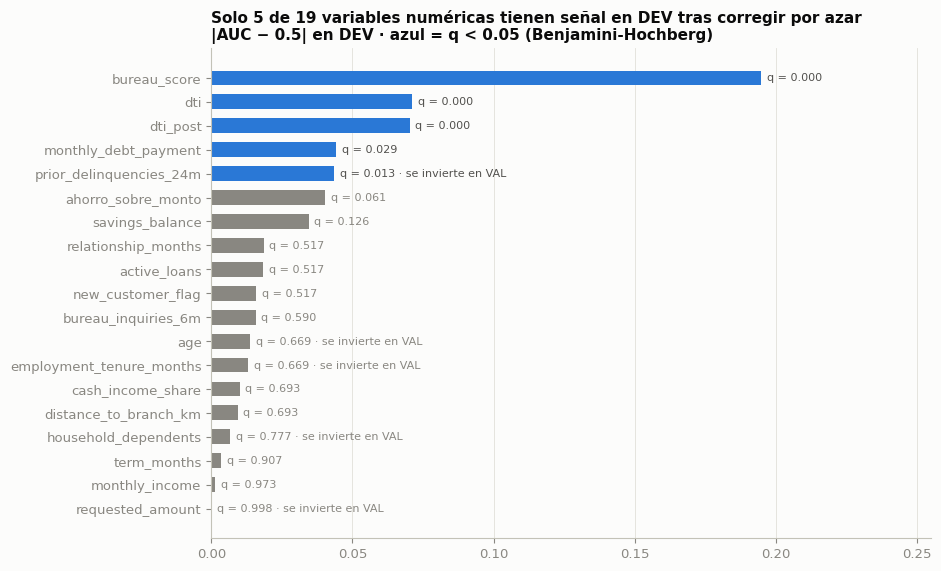

In [3]:
scr = eda.univariate_screening(dev, val, nums, cats)
display(scr)
scr.to_csv(cfg.TABLES / "eda_tamizaje_variables.csv", index=False)
senal = scr.loc[scr["senal_en_dev"], "variable"].tolist()
print(f"Con señal en DEV (q < 0.05): {len(senal)} de {len(scr)} -> {senal}")
print("Con señal en DEV pero con dirección invertida en VAL:",
      scr.loc[scr["senal_en_dev"] & (scr["misma_direccion_en_val"] == False), "variable"].tolist())

num = scr[scr["tipo"] == "numérica"].assign(fuerza=lambda d: (d["auc_dev"] - 0.5).abs()).sort_values("fuerza")
fig, ax = plt.subplots(figsize=(9.5, 5.8))
ax.barh(num["variable"], num["fuerza"], color=[BLUE if s else MUTED for s in num["senal_en_dev"]], height=0.62)
for y_, (_, r) in enumerate(num.iterrows()):
    nota = f"q = {r.q_bh:.3f}" + ("" if r.misma_direccion_en_val else " · se invierte en VAL")
    ax.text(r.fuerza + 0.002, y_, nota, va="center", fontsize=8, color=INK_2 if r.senal_en_dev else MUTED)
ax.set_xlim(0, num["fuerza"].max() + 0.06)
ax.set_title(f"Solo {int(num['senal_en_dev'].sum())} de {len(num)} variables numéricas tienen señal en DEV tras corregir por azar\n"
             "|AUC − 0.5| en DEV · azul = q < 0.05 (Benjamini-Hochberg)")
ax.grid(axis="y", visible=False)
fig.tight_layout(); savefig(fig, "fig11_tamizaje_variables"); plt.show()

**Hallazgo 1 · La señal está concentrada.** Solo 5 variables tienen asociación real con el default en DEV tras corregir por azar: `bureau_score`, `dti`, `dti_post`, `prior_delinquencies_24m` y `monthly_debt_payment`; `ahorro_sobre_monto` queda al borde (q = 0.06). Ninguna categórica (región, canal, tipo de empleo) pasa el filtro. Además, `prior_delinquencies_24m` invierte su dirección en VAL.
*Impacto:* el scorecard debe ser **parsimonioso** (3 a 4 características). Agregar variables sin señal suma ruido y sobreajuste.

## 2. ¿Qué tan fuerte y estable es el buró?

,dev_creditos,dev_default_rate,dev_ic_inf,dev_ic_sup,val_creditos,val_default_rate,val_ic_inf,val_ic_sup
tramo,,,,,,,,
"(-inf, 577.0]",334,0.2665,0.2219,0.3163,98,0.2857,0.2057,0.3819
"(577.0, 611.0]",342,0.1725,0.1362,0.2161,115,0.2348,0.1667,0.3200
"(611.0, 632.0]",323,0.1176,0.0869,0.1574,99,0.2121,0.1431,0.3026
"(632.0, 652.0]",336,0.1220,0.0912,0.1614,110,0.1545,0.0988,0.2336
"(652.0, 670.0]",333,0.0811,0.0563,0.1154,109,0.1468,0.0924,0.2252
"(670.0, 689.0]",331,0.0816,0.0567,0.1161,116,0.1293,0.0800,0.2024
"(689.0, 709.0]",340,0.0676,0.0455,0.0995,123,0.1138,0.0690,0.1820
"(709.0, 732.0]",324,0.0679,0.0453,0.1007,124,0.0806,0.0444,0.1421
"(732.0, 764.0]",324,0.0340,0.0191,0.0598,103,0.0874,0.0467,0.1578


,2021,2022,2023,2024
AUC del buró,0.7039,0.6697,0.7082,0.6752


,agencia,alianza,app,web
AUC del buró en DEV,0.6957,0.6621,0.7053,0.6922


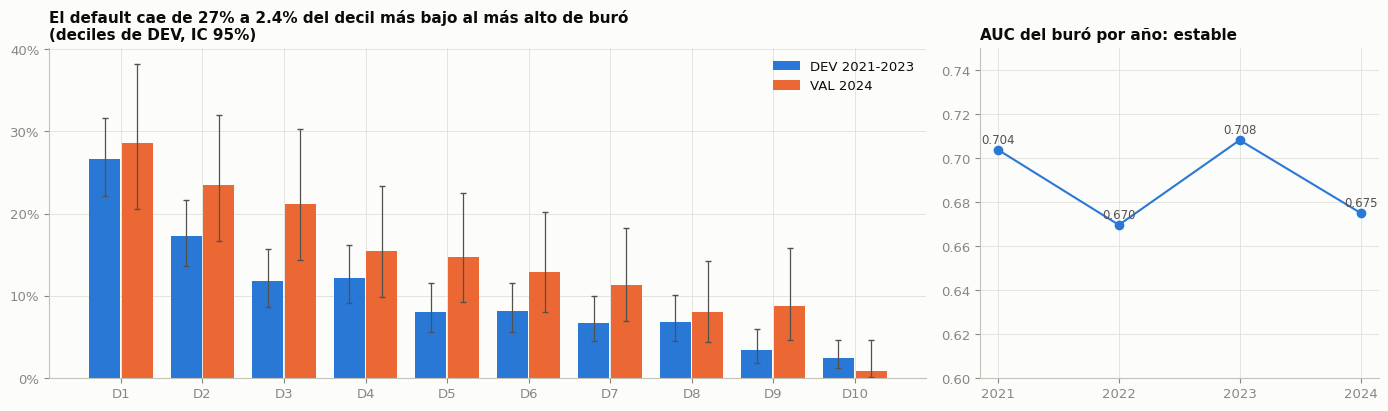

In [4]:
buro = eda.compare_samples(muestras, "bureau_score", q=10)
display(buro)
buro.to_csv(cfg.TABLES / "eda_buro_deciles.csv")
anual = dv.groupby(dv[cfg.DATE_COL].dt.year)
auc_anio = pd.Series({y: validation.auc_raw(g[T], -g["bureau_score"]) for y, g in anual}, name="AUC del buró")
auc_canal = pd.Series({c: validation.auc_raw(g[T], -g["bureau_score"]) for c, g in dev.groupby("channel")}, name="AUC del buró en DEV")
display(auc_anio.to_frame().T, auc_canal.to_frame().T)

d10 = buro.drop(index="Faltante", errors="ignore")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [2.2, 1]})
etiquetas = [f"D{i+1}" for i in range(len(d10))]
barras_con_ic(axes[0], etiquetas, d10["dev_default_rate"], d10["dev_ic_inf"], d10["dev_ic_sup"], BLUE, desplazamiento=-0.2, etiqueta="DEV 2021-2023", valores=False)
barras_con_ic(axes[0], etiquetas, d10["val_default_rate"], d10["val_ic_inf"], d10["val_ic_sup"], ORANGE, desplazamiento=0.2, etiqueta="VAL 2024", valores=False)
axes[0].set_xticks(np.arange(len(etiquetas)), etiquetas)
axes[0].set_title(f"El default cae de {d10['dev_default_rate'].iloc[0]:.0%} a {d10['dev_default_rate'].iloc[-1]:.1%} del decil más bajo al más alto de buró\n(deciles de DEV, IC 95%)")
axes[0].legend(loc="upper right"); pct_axis(axes[0])
axes[1].plot(auc_anio.index.astype(str), auc_anio.values, marker="o", color=BLUE)
for x_, v in zip(auc_anio.index.astype(str), auc_anio.values):
    axes[1].text(x_, v + 0.003, f"{v:.3f}", ha="center", fontsize=8.5, color=INK_2)
axes[1].set_ylim(0.6, 0.75); axes[1].set_title("AUC del buró por año: estable")
fig.tight_layout(); savefig(fig, "fig12_buro"); plt.show()

**Hallazgo 2 · El buró es el eje del riesgo y ordena igual en el tiempo y en todos los canales.** En DEV el default cae de 26.6% en el decil más bajo a 2.4% en el más alto (11 veces), y VAL repite el orden con tasas más altas. El AUC por año se mueve entre 0.67 y 0.71 sin tendencia, y en DEV es similar en los cuatro canales (0.66 a 0.71). La tendencia no es perfecta decil a decil (hay mesetas), lo que anticipa que el binning agrupará tramos.
*Impacto:* es la característica principal del scorecard, con tramos monótonos. Al medirse en T0 no hay leakage, aunque su IV alto se revisará en 6.5. Como ordena igual en todos los canales, no hace falta un scorecard por canal.

## 3. El default subió: ¿cambió el nivel o la capacidad de ordenar? ¿Salto o tendencia?

Se compara DEV con VAL en una logística con el buró estandarizado: un término de **nivel** (intercepto de VAL) y uno de **pendiente** (interacción buró × VAL). Después se miran las cohortes trimestrales de 2021 a 2024.

*Nota sobre vintages:* el archivo trae el flag de default a 12 meses, pero no la fecha del default ni la mora mes a mes. Por eso no se pueden construir curvas de vintage por meses en libros; se analizan **cohortes de originación con su tasa a 12 meses**.

,cambio_log_odds,odds_ratio_val,p_nivel,pendiente_dev,cambio_pendiente,p_pendiente
valor,0.4199,1.5218,0.0001,-0.7367,0.0760,0.4941


,log_odds_dev,log_odds_val,diferencia_val_menos_dev
tramo,,,
"(-inf, 611.0]",-1.2719,-1.0553,0.2166
"(611.0, 652.0]",-1.9936,-1.5041,0.4895
"(652.0, 689.0]",-2.4245,-1.8339,0.5906
"(689.0, 732.0]",-2.6214,-2.2291,0.3923
"(732.0, inf]",-3.5092,-3.0493,0.4599


observation_date,2021Q1,2021Q2,2021Q3,2021Q4,2022Q1,2022Q2,2022Q3,2022Q4,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4
creditos,317.0000,303.0000,291.0000,270.0000,277.0000,306.0000,286.0000,277.0000,277.0000,281.0000,306.0000,252.0000,274.0000,265.0000,337.0000,275.0000
defaults,30.0000,26.0000,28.0000,18.0000,23.0000,31.0000,34.0000,23.0000,30.0000,42.0000,36.0000,30.0000,35.0000,34.0000,45.0000,47.0000
default_rate,0.0946,0.0858,0.0962,0.0667,0.0830,0.1013,0.1189,0.0830,0.1083,0.1495,0.1176,0.1190,0.1277,0.1283,0.1335,0.1709
ic_inf,0.0671,0.0592,0.0674,0.0426,0.0560,0.0723,0.0863,0.0560,0.0769,0.1125,0.0862,0.0847,0.0933,0.0933,0.1013,0.1310
ic_sup,0.1319,0.1228,0.1356,0.1029,0.1215,0.1402,0.1615,0.1215,0.1504,0.1959,0.1586,0.1649,0.1725,0.1739,0.1740,0.2199


,odds_ratio_anual,p_tendencia,p_escalon_sobre_tendencia,p_tendencia_sobre_escalon
valor,1.2000,0.0000,0.3796,0.1400


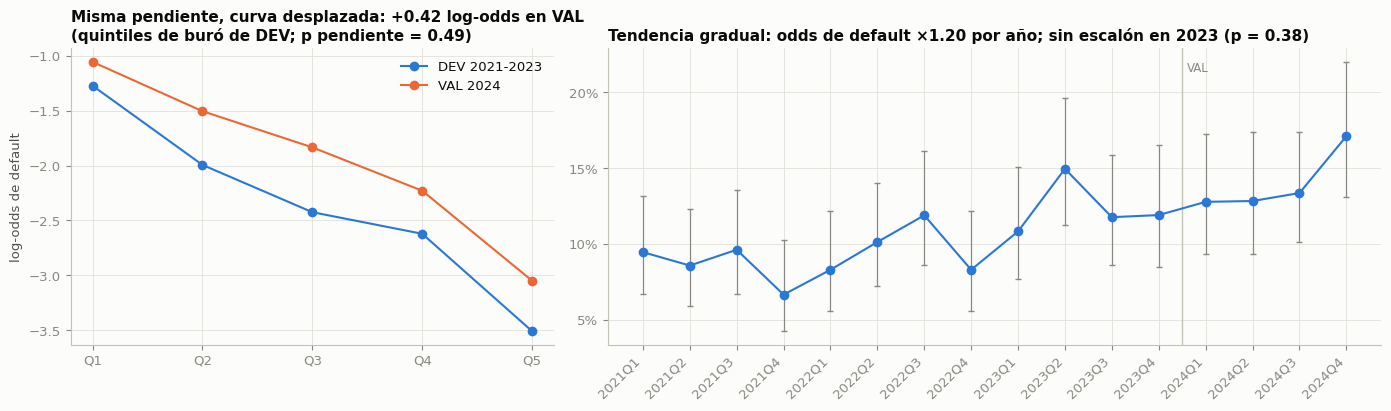

In [5]:
lvl = eda.level_shift_test(dev, val, "bureau_score")
display(pd.Series(lvl).to_frame("valor").T)
q5 = eda.compare_samples(muestras, "bureau_score", q=5).drop(index="Faltante", errors="ignore")
logit = lambda p: np.log(p / (1 - p))
lo = pd.DataFrame({"log_odds_dev": logit(q5["dev_default_rate"]), "log_odds_val": logit(q5["val_default_rate"])})
lo["diferencia_val_menos_dev"] = lo["log_odds_val"] - lo["log_odds_dev"]
display(lo)

coh, coh_res = eda.cohort_trend(dv)
display(coh.T)
display(pd.Series(coh_res).to_frame("valor").T)
coh.to_csv(cfg.TABLES / "eda_cohortes_trimestrales.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1, 1.6]})
x = [f"Q{i+1}" for i in range(len(lo))]
axes[0].plot(x, lo["log_odds_dev"], marker="o", color=BLUE, label="DEV 2021-2023")
axes[0].plot(x, lo["log_odds_val"], marker="o", color=ORANGE, label="VAL 2024")
axes[0].set_title(f"Misma pendiente, curva desplazada: +{lvl['cambio_log_odds']:.2f} log-odds en VAL\n(quintiles de buró de DEV; p pendiente = {lvl['p_pendiente']:.2f})")
axes[0].set_ylabel("log-odds de default"); axes[0].legend()
q = coh.index.astype(str)
axes[1].errorbar(q, coh["default_rate"], yerr=[coh["default_rate"] - coh["ic_inf"], coh["ic_sup"] - coh["default_rate"]],
                 fmt="o-", color=BLUE, ecolor=MUTED, elinewidth=0.9, capsize=2)
axes[1].axvline(11.5, color=AXIS, lw=1); axes[1].text(11.6, coh["ic_sup"].max(), "VAL", color=MUTED, fontsize=8.5, va="top")
axes[1].set_title(f"Tendencia gradual: odds de default ×{coh_res['odds_ratio_anual']:.2f} por año; sin escalón en 2023 (p = {coh_res['p_escalon_sobre_tendencia']:.2f})")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right"); pct_axis(axes[1])
fig.tight_layout(); savefig(fig, "fig13_nivel_y_tendencia"); plt.show()

**Hallazgo 3 · El deterioro es de nivel, no de capacidad de ordenar.** A igual score, VAL tiene +0.42 log-odds de default (odds 1.52 veces mayores, p < 0.001), pero la pendiente del buró no cambia (p = 0.49): la curva de riesgo se desplazó en paralelo.
*Impacto:* un scorecard ajustado en DEV ordenará bien en 2024, pero **subestimará la PD**. La corrección natural es recalibrar el intercepto (Platt) con VAL en 6.7, y conviene separar el score (orden) de la tabla score → PD (nivel), que es la que se recalibra.

**Hallazgo 4 · No fue un salto en 2023: es una tendencia gradual.** Las cohortes trimestrales 2021-2024 muestran odds de default que crecen 20% por año (p < 0.001), y un escalón en 2023 no agrega nada sobre la tendencia (p = 0.38).
*Impacto:* el nivel de PD envejece rápido. Hacen falta (i) calibrar con la ventana más reciente, (ii) un disparador de recalibración por brecha entre PD predicha y default observado, y (iii) un escenario Adverse de stress que prolongue la tendencia. El monitoreo debe comparar cohortes trimestrales, no solo años.

## 4. ¿Cómo pesa la capacidad de pago y cómo se combina con el buró?

,dev_creditos,dev_default_rate,dev_ic_inf,dev_ic_sup,val_creditos,val_default_rate,val_ic_inf,val_ic_sup
tramo,,,,,,,,
"(-inf, 0.3]",933,0.0857,0.0694,0.1055,310,0.1258,0.0934,0.1674
"(0.3, 0.45]",1004,0.0797,0.0645,0.0981,352,0.1136,0.0846,0.1510
"(0.45, 0.6]",777,0.1120,0.0917,0.1361,245,0.1755,0.1330,0.2280
"(0.6, 0.8]",489,0.1554,0.1260,0.1902,166,0.1988,0.1452,0.2660
"(0.8, inf]",155,0.1355,0.0904,0.1982,51,0.0784,0.0309,0.1850
Faltante,85,0.0824,0.0405,0.1604,27,0.0741,0.0206,0.2337


Interacción buró x dti_post en DEV (terciles): p = 0.896 con 4 gl


dti_post,dti_post_T1,dti_post_T2,dti_post_T3
bureau_score,,,
bureau_score_T1,0.1501,0.1630,0.2429
bureau_score_T2,0.0580,0.0732,0.1243
bureau_score_T3,0.0376,0.0309,0.0601


dti_post,dti_post_T1,dti_post_T2,dti_post_T3
bureau_score,,,
bureau_score_T1,373,368,354
bureau_score_T2,362,355,354
bureau_score_T3,346,356,366


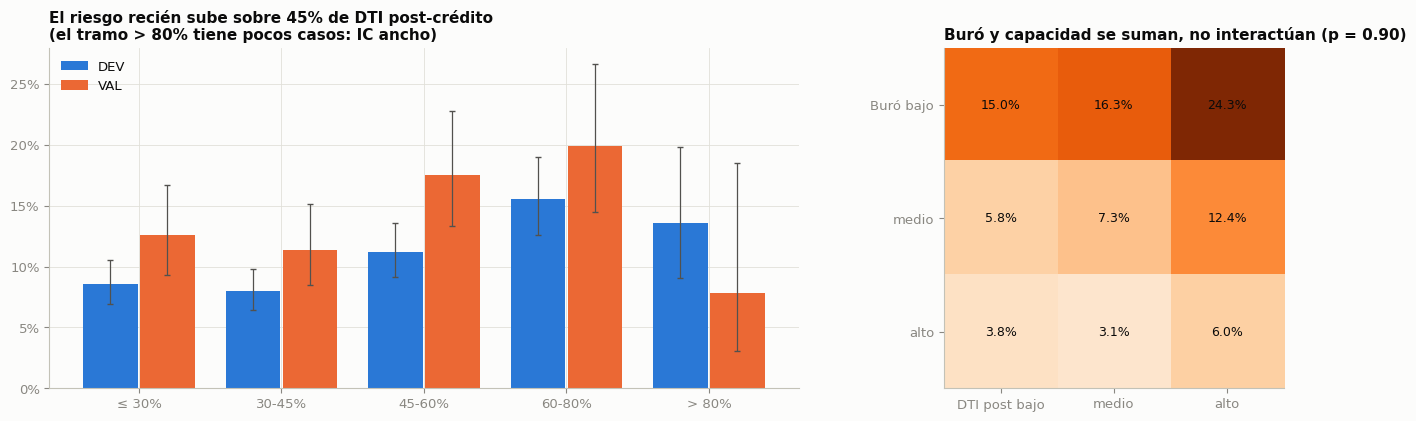

In [6]:
cortes_cap = [-np.inf, 0.30, cfg.DTI_POST_AUTO_MAX, cfg.DTI_POST_HARD_MAX, 0.80, np.inf]
cap = eda.compare_samples(muestras, "dti_post", edges=cortes_cap)
display(cap)
cap.to_csv(cfg.TABLES / "eda_capacidad_dti_post.csv")
inter = eda.interaction_test(dev, "bureau_score", "dti_post")
print(f"Interacción buró x dti_post en DEV (terciles): p = {inter['p_interaccion']:.3f} con {inter['gl']} gl")
display(inter["default_rate"], inter["creditos"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.3), gridspec_kw={"width_ratios": [1.4, 1]})
c = cap.drop(index="Faltante", errors="ignore")
etq = ["≤ 30%", "30-45%", "45-60%", "60-80%", "> 80%"]
barras_con_ic(axes[0], etq, c["dev_default_rate"], c["dev_ic_inf"], c["dev_ic_sup"], BLUE, desplazamiento=-0.2, etiqueta="DEV", valores=False)
barras_con_ic(axes[0], etq, c["val_default_rate"], c["val_ic_inf"], c["val_ic_sup"], ORANGE, desplazamiento=0.2, etiqueta="VAL", valores=False)
axes[0].set_xticks(np.arange(len(etq)), etq); pct_axis(axes[0]); axes[0].legend(loc="upper left")
axes[0].set_title("El riesgo recién sube sobre 45% de DTI post-crédito\n(el tramo > 80% tiene pocos casos: IC ancho)")
m = inter["default_rate"].to_numpy()
im = axes[1].imshow(m, cmap="Oranges", vmin=0, vmax=np.nanmax(m))
for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        axes[1].text(j, i, f"{m[i, j]:.1%}", ha="center", va="center", fontsize=9, color=INK)
axes[1].set_xticks(range(3), ["DTI post bajo", "medio", "alto"]); axes[1].set_yticks(range(3), ["Buró bajo", "medio", "alto"])
axes[1].grid(False)
axes[1].set_title(f"Buró y capacidad se suman, no interactúan (p = {inter['p_interaccion']:.2f})")
fig.tight_layout(); savefig(fig, "fig14_capacidad_e_interaccion"); plt.show()

**Hallazgo 5 · La capacidad de pago tiene un umbral.** Con DTI post-crédito de hasta 45% el default es plano (8.0%-8.6% en DEV). Entre 45% y 60% sube a 11.2%, y entre 60% y 80% a 15.5%. VAL repite el quiebre en 45%. El tramo > 80% tiene pocos casos y un IC ancho, así que no permite leer una baja.
*Impacto:* una relación lineal subestimaría el quiebre, mientras que un tramo "≤ 45%" sin penalidad refleja bien los datos. Sustenta la regla de capacidad de 6.1 (automático hasta 45%, tope duro en 60%).

**Hallazgo 6 · Buró y capacidad se suman, no interactúan.** En DEV el default va de 3.8% (buró alto con DTI post bajo) a 24.3% (buró bajo con DTI post alto), y los términos de interacción no aportan (p = 0.90).
*Impacto:* un scorecard aditivo (logística sobre WOE) captura la estructura. No hay que esperar que un modelo de ML gane por interacciones entre estas dos variables, y la política puede expresarse como una matriz banda de score × capacidad.

## 5. ¿El historial de mora y las consultas agregan riesgo?

In [7]:
historial = pd.concat({
    "prior_delinquencies_24m (0 / 1 / 2+)": eda.compare_samples(muestras, "prior_delinquencies_24m", edges=[-np.inf, 0, 1, np.inf]),
    "bureau_inquiries_6m (0 / 1-2 / 3+)": eda.compare_samples(muestras, "bureau_inquiries_6m", edges=[-np.inf, 0, 2, np.inf]),
    "active_loans (0-1 / 2-3 / 4+)": eda.compare_samples(muestras, "active_loans", edges=[-np.inf, 1, 3, np.inf]),
})
display(historial)
historial.to_csv(cfg.TABLES / "eda_historial_credito.csv")
mora_anio = dv.assign(mora=pd.cut(dv["prior_delinquencies_24m"], [-np.inf, 0, 1, np.inf], labels=["0", "1", "2+"])) \
    .pivot_table(index=dv[cfg.DATE_COL].dt.year, columns="mora", values=T, aggfunc="mean", observed=True)
display(mora_anio.rename_axis("anio"))

dev_creditos  dev_default_rate  dev_ic_inf  dev_ic_sup  val_creditos  val_default_rate  val_ic_inf  val_ic_sup
                                     tramo                                                                                                                      
prior_delinquencies_24m (0 / 1 / 2+) (-inf, 0.0]          1978            0.0885      0.0767      0.1018           662            0.1465      0.1216      0.1755
                                     (0.0, 1.0]           1098            0.1175      0.0998      0.1379           377            0.1194      0.0904      0.1560
                                     (1.0, inf]            367            0.1281      0.0977      0.1661           112            0.1696      0.1114      0.2498
bureau_inquiries_6m (0 / 1-2 / 3+)   (-inf, 0.0]           559            0.0859      0.0654      0.1120           209            0.1148      0.0784      0.1652
                                     (0.0, 2.0]           1942            0.1020      0.0893      0.1162           649            0.1510      0.1255      0.1806
                                     (2.0, inf]            942            0.1115      0.0929      0.1332           293            0.1331      0.0989      0.1768
active_loans (0-1 / 2-3 / 4+)        (-inf, 1.0]          1402            0.1098      0.0945      0.1273           455            0.1516      0.1216      0.1875
                                     (1.0, 3.0]           1515            0.0990      0.0850      0.1151           525            0.1181      0.0932      0.1485
                                     (3.0, inf]            526            0.0894      0.0679      0.1168           171            0.1754      0.1257      0.2394

mora,0,1,2+
anio,,,
2021,0.0821,0.0897,0.0977
2022,0.0784,0.1271,0.1111
2023,0.1056,0.1387,0.1746
2024,0.1465,0.1194,0.1696


**Hallazgo 7 · La mora previa ordena en DEV, pero no se sostiene en VAL.** En DEV el default sube de 8.8% sin moras a 11.7% con una y 12.8% con dos o más, en cada uno de los tres años. En VAL la relación se invierte entre 0 y 1 mora (14.7% vs 11.9%). Consultas al buró y número de créditos activos no ordenan en ninguna muestra.
*Impacto:* es candidata al scorecard por DEV, pero debe probar en VAL que no se invierte antes de entrar (criterio S6 de 6.5). Si queda fuera, se vigila en el monitoreo como variable a reevaluar.

## 6. ¿Crecer por canales digitales y con clientes nuevos aumenta el riesgo?

,dev_creditos,dev_default_rate,dev_ic_inf,dev_ic_sup,val_creditos,val_default_rate,val_ic_inf,val_ic_sup
tramo,,,,,,,,
agencia,748,0.1163,0.0953,0.1413,248,0.1089,0.0759,0.1538
alianza,337,0.0890,0.0631,0.1242,98,0.1224,0.0715,0.2019
app,1144,0.0970,0.0812,0.1156,383,0.1227,0.0936,0.1594
web,1214,0.1013,0.0856,0.1196,422,0.1777,0.1442,0.2171


Chi² canal x default: {'DEV': np.float64(0.456), 'VAL': np.float64(0.042)} | aprobación TTD en DEV por canal: {'agencia': 0.823, 'alianza': 0.824, 'app': 0.832, 'web': 0.831}


,creditos_con,default_con,creditos_sin,default_sin,brecha_pp,p_fisher
anio,,,,,,
2021,526,0.0837,655,0.0885,-0.4899,0.8350
2022,510,0.1000,636,0.0943,0.5660,0.7638
2023,514,0.1420,602,0.1080,3.4050,0.1004
2024,484,0.1674,667,0.1199,4.7415,0.0251


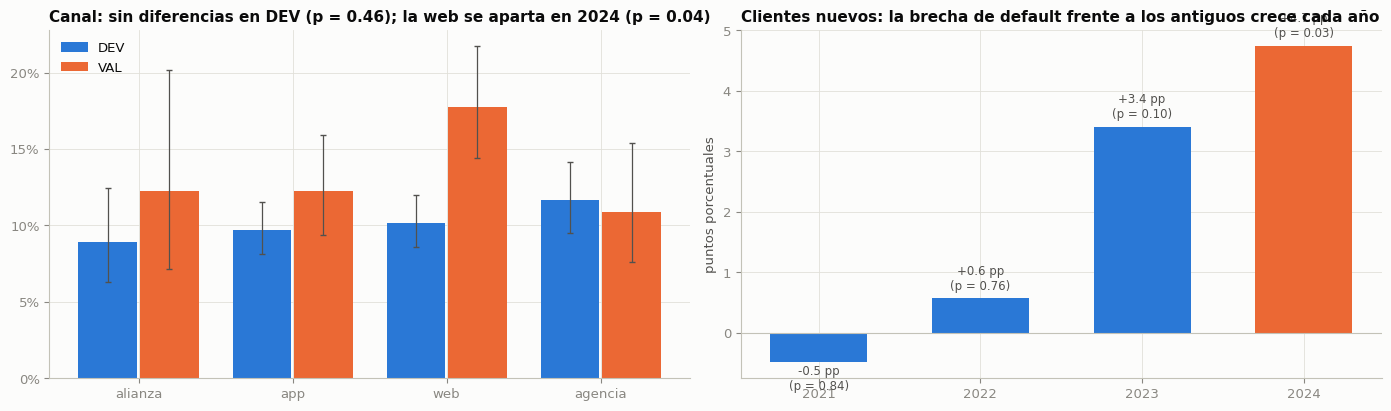

In [8]:
canal = eda.compare_samples(muestras, "channel")
display(canal)
p_canal = {s: stats.chi2_contingency(pd.crosstab(d["channel"], d[T]))[1] for s, d in muestras.items()}
aprob_canal = ttd_dev.groupby("channel")[cfg.APPROVED_FLAG].mean()
print("Chi² canal x default:", {k: round(v, 3) for k, v in p_canal.items()}, "| aprobación TTD en DEV por canal:", aprob_canal.round(3).to_dict())

nuevos = eda.gap_by_year(dv, dv["new_customer_flag"])
display(nuevos)
nuevos.to_csv(cfg.TABLES / "eda_clientes_nuevos_por_anio.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
cc = canal.sort_values("dev_default_rate")
barras_con_ic(axes[0], cc.index, cc["dev_default_rate"], cc["dev_ic_inf"], cc["dev_ic_sup"], BLUE, desplazamiento=-0.2, etiqueta="DEV", valores=False)
barras_con_ic(axes[0], cc.index, cc["val_default_rate"], cc["val_ic_inf"], cc["val_ic_sup"], ORANGE, desplazamiento=0.2, etiqueta="VAL", valores=False)
axes[0].set_xticks(np.arange(len(cc)), cc.index); pct_axis(axes[0]); axes[0].legend(loc="upper left")
axes[0].set_title(f"Canal: sin diferencias en DEV (p = {p_canal['DEV']:.2f}); la web se aparta en 2024 (p = {p_canal['VAL']:.2f})")
axes[1].bar(nuevos.index.astype(str), nuevos["brecha_pp"], color=[BLUE if y <= 2023 else ORANGE for y in nuevos.index], width=0.6)
for x_, (v, p) in enumerate(zip(nuevos["brecha_pp"], nuevos["p_fisher"])):
    axes[1].text(x_, v + (0.15 if v >= 0 else -0.45), f"{v:+.1f} pp\n(p = {p:.2f})", ha="center", fontsize=8.5, color=INK_2)
axes[1].axhline(0, color=AXIS, lw=0.8)
axes[1].set_title("Clientes nuevos: la brecha de default frente a los antiguos crece cada año")
axes[1].set_ylabel("puntos porcentuales")
fig.tight_layout(); savefig(fig, "fig15_canal_y_clientes_nuevos"); plt.show()

**Hallazgo 8 · Crecer por canales digitales no aumentó el riesgo en DEV, pero la web se aparta en 2024.** En DEV el default por canal va de 8.9% (alianza) a 11.6% (agencia), sin diferencia significativa (p = 0.46). La aprobación y la capacidad de ordenar del buró son iguales en los cuatro canales. En VAL la web sube a 17.8% frente a 10.9%-12.3% del resto (p = 0.04). Es una sola señal de un año, entre varias pruebas de segmento: se trata como alerta, no como conclusión.
*Impacto:* el canal no entra al modelo, y la evidencia de DEV respalda crecer fuera de agencias. Se agrega un **indicador de monitoreo por canal** (default de la web frente al resto) y conviene revisar los controles de identidad y verificación del flujo web.

**Hallazgo 9 · La brecha de riesgo de los clientes nuevos crece cada año.** La diferencia de default entre nuevos y antiguos pasa de −0.5 pp (2021) a +0.6 pp (2022), +3.4 pp (2023) y +4.7 pp (2024, p = 0.03). En DEV agregado no es significativa (p = 0.26), así que un scorecard ajustado en DEV no la va a capturar.
*Impacto:* riesgo de **subestimar a los clientes nuevos en producción**. Conviene monitorear el default de nuevos vs. antiguos por cohorte, mantener el límite de concentración de clientes nuevos del apetito, acotar el monto del primer crédito y reevaluar la variable en la próxima recalibración.

## 7. ¿Informalidad, territorio, hogar o edad cambian el riesgo?

Son las variables de la revisión de fairness del catálogo (6.2). La pregunta no es solo si predicen, sino si hay **necesidad de negocio** para usarlas.

cash_income_share


,dev_creditos,dev_default_rate,dev_ic_inf,dev_ic_sup,val_creditos,val_default_rate,val_ic_inf,val_ic_sup
tramo,,,,,,,,
"(-inf, 0.411]",689,0.1045,0.0838,0.1296,220,0.1500,0.1088,0.2032
"(0.411, 0.548]",688,0.0959,0.0761,0.1202,213,0.1315,0.0925,0.1834
"(0.548, 0.669]",689,0.0943,0.0747,0.1185,261,0.1264,0.0915,0.1722
"(0.669, 0.786]",688,0.0974,0.0774,0.1218,222,0.1036,0.0700,0.1507
"(0.786, inf]",689,0.1176,0.0956,0.1438,235,0.1872,0.1425,0.2420


region


,dev_creditos,dev_default_rate,dev_ic_inf,dev_ic_sup,val_creditos,val_default_rate,val_ic_inf,val_ic_sup
tramo,,,,,,,,
Centro,529,0.0907,0.0691,0.1183,181,0.1547,0.1092,0.2145
Lima,1420,0.1141,0.0986,0.1317,488,0.1516,0.1225,0.1862
Norte,667,0.1079,0.0866,0.1338,193,0.1451,0.1023,0.2017
Oriente,329,0.0942,0.0672,0.1306,102,0.0882,0.0471,0.1592
Sur,498,0.0763,0.0561,0.1030,187,0.1176,0.0790,0.1717


distance_to_branch_km


...

household_dependents


,dev_creditos,dev_default_rate,dev_ic_inf,dev_ic_sup,val_creditos,val_default_rate,val_ic_inf,val_ic_sup
tramo,,,,,,,,
"(-inf, 0.0]",391,0.0997,0.0738,0.1335,104,0.1635,0.1046,0.2463
"(0.0, 1.0]",824,0.1068,0.0875,0.1297,292,0.1473,0.1112,0.1925
"(1.0, 2.0]",901,0.0932,0.0759,0.1140,301,0.1395,0.1049,0.1832
"(2.0, 3.0]",698,0.1003,0.0801,0.1248,234,0.1154,0.0805,0.1627
"(3.0, inf]",629,0.1113,0.0890,0.1383,220,0.1455,0.1050,0.1981


age


,dev_creditos,dev_default_rate,dev_ic_inf,dev_ic_sup,val_creditos,val_default_rate,val_ic_inf,val_ic_sup
tramo,,,,,,,,
"(-inf, 25.0]",331,0.0937,0.0668,0.1299,109,0.1376,0.0852,0.2147
"(25.0, 35.0]",1072,0.0951,0.0790,0.1142,341,0.1613,0.1261,0.2041
"(35.0, 45.0]",1261,0.1071,0.0912,0.1253,423,0.1253,0.0971,0.1603
"(45.0, 55.0]",654,0.1101,0.0883,0.1364,232,0.1466,0.1068,0.1978
"(55.0, inf]",125,0.0880,0.0498,0.1507,46,0.0870,0.0343,0.2032


Chi² región x default: {'DEV': np.float64(0.133), 'VAL': np.float64(0.411)} | aprobación TTD en DEV por región: {'Centro': 0.844, 'Lima': 0.829, 'Norte': 0.841, 'Oriente': 0.818, 'Sur': 0.805} (p = 0.32)


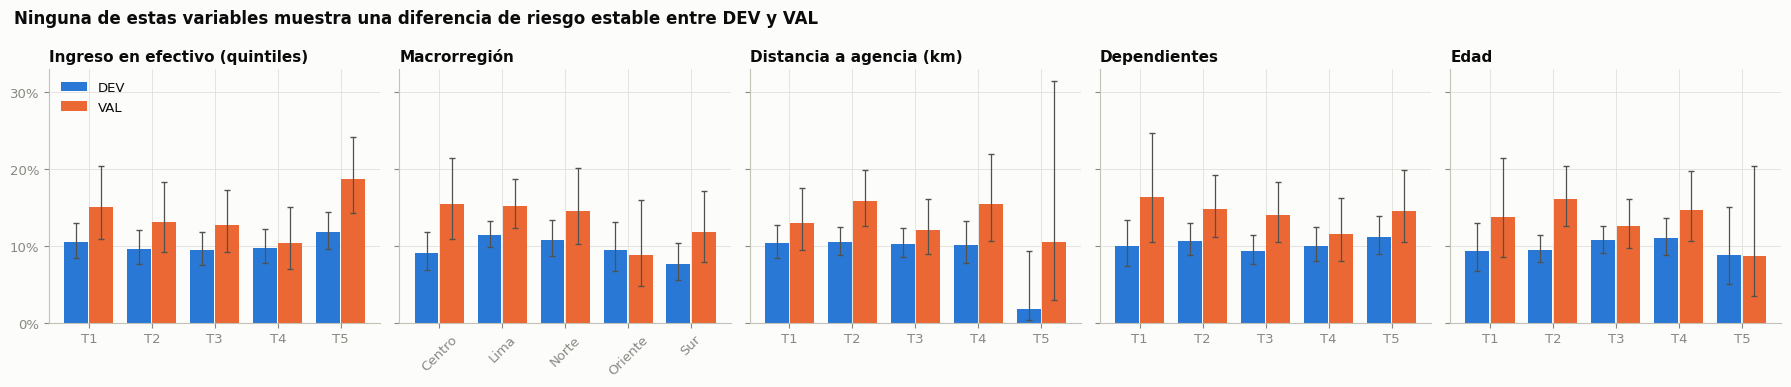

In [9]:
bloques = {
    "cash_income_share": eda.compare_samples(muestras, "cash_income_share", q=5),
    "region": eda.compare_samples(muestras, "region"),
    "distance_to_branch_km": eda.compare_samples(muestras, "distance_to_branch_km", edges=[-np.inf, 5, 10, 20, 50, np.inf]),
    "household_dependents": eda.compare_samples(muestras, "household_dependents", edges=[-np.inf, 0, 1, 2, 3, np.inf]),
    "age": eda.compare_samples(muestras, "age", edges=[-np.inf, 25, 35, 45, 55, np.inf]),
}
for k, t in bloques.items():
    print(k); display(t)
pd.concat(bloques).to_csv(cfg.TABLES / "eda_fairness_variables.csv")
p_region = {s: stats.chi2_contingency(pd.crosstab(d["region"], d[T]))[1] for s, d in muestras.items()}
print("Chi² región x default:", {k: round(v, 3) for k, v in p_region.items()},
      "| aprobación TTD en DEV por región:", ttd_dev.groupby("region")[cfg.APPROVED_FLAG].mean().round(3).to_dict(),
      f"(p = {stats.chi2_contingency(pd.crosstab(ttd_dev['region'], ttd_dev[cfg.APPROVED_FLAG]))[1]:.2f})")

titulos = {"cash_income_share": "Ingreso en efectivo (quintiles)", "region": "Macrorregión", "distance_to_branch_km": "Distancia a agencia (km)",
           "household_dependents": "Dependientes", "age": "Edad"}
fig, axes = plt.subplots(1, 5, figsize=(18, 3.9), sharey=True)
for ax, (k, t) in zip(axes, bloques.items()):
    t = t.drop(index="Faltante", errors="ignore")
    etq = [str(i)[:14] for i in t.index] if k == "region" else [f"T{i+1}" for i in range(len(t))]
    barras_con_ic(ax, etq, t["dev_default_rate"], t["dev_ic_inf"], t["dev_ic_sup"], BLUE, desplazamiento=-0.2, etiqueta="DEV", valores=False)
    barras_con_ic(ax, etq, t["val_default_rate"], t["val_ic_inf"], t["val_ic_sup"], ORANGE, desplazamiento=0.2, etiqueta="VAL", valores=False)
    ax.set_xticks(np.arange(len(etq)), etq, rotation=45 if k == "region" else 0); ax.set_title(titulos[k]); pct_axis(ax)
axes[0].legend(loc="upper left")
fig.suptitle("Ninguna de estas variables muestra una diferencia de riesgo estable entre DEV y VAL", x=0.01, ha="left", fontweight="bold", fontsize=12)
fig.tight_layout(); savefig(fig, "fig16_variables_fairness"); plt.show()

**Hallazgo 10 · El ingreso en efectivo solo muestra algo más de riesgo en el quintil más alto, y no de forma estable.** En DEV el quintil superior tiene 11.8% frente a 9.4%-10.4% del resto, dentro del ruido (p = 0.14). En VAL la diferencia se amplía (18.7% frente a 10.4%-15.0%, p = 0.03): es un año, y va en línea con la brecha de 2024 que ya se vio en 6.3.
*Impacto:* no hay necesidad de negocio para usar la informalidad en el modelo, y usarla contradice el objetivo del caso. Se aplica verificación del ingreso en efectivo en tickets altos (6.1 §8), se monitorea el default del segmento y se mantiene el AIR por efectivo en el apetito.

**Hallazgo 11 · Territorio, distancia, dependientes y edad no cambian el riesgo.** La región no difiere en DEV (p = 0.13) ni en VAL (p = 0.41), y la región con menor default cambia de una muestra a otra (Sur en DEV, Oriente en VAL). La distancia es plana hasta 50 km, y dependientes y edad no muestran patrón. Ninguna pasa el tamizaje de la sección 1.
*Impacto:* se **excluyen del scorecard por diseño**, sin costo predictivo (6.5 lo verifica con IV). Se conservan solo para medir fairness (AIR territorial) en 6.8, y "cuesta más atender lejos" sigue siendo un supuesto.

## 8. ¿Monto y plazo cambian la PD? ¿Dónde se concentra la exposición?

In [10]:
monto = eda.compare_samples(muestras, "requested_amount", q=5)
plazo = eda.compare_samples(muestras, "term_months")
display(monto, plazo)
p_monto = validation.auc_test(dev[T], dev["requested_amount"])
p_plazo = validation.auc_test(dev[T], dev["term_months"])
print(f"Monto en DEV: AUC {p_monto[0]:.3f} (p = {p_monto[1]:.2f}) | Plazo en DEV: AUC {p_plazo[0]:.3f} (p = {p_plazo[1]:.2f})")

# Tickets grandes, muestra por muestra: el promedio de DEV + VAL esconde que el riesgo se invierte.
filas = []
for s, d in muestras.items():
    g = d["requested_amount"].gt(cfg.MICRO_MAX_AUTO_AMOUNT)
    perd = d["ead_at_default"].fillna(0) * d["lgd_observed"].fillna(0)
    lo, hi = eda.wilson_ci(np.array([d.loc[g, T].sum()]), np.array([g.sum()]))
    filas.append({"muestra": s, "creditos_gt_20k": int(g.sum()), "defaults_gt_20k": int(d.loc[g, T].sum()),
                  "default_gt_20k": d.loc[g, T].mean(), "ic_inf": lo[0], "ic_sup": hi[0], "default_resto": d.loc[~g, T].mean(),
                  "p_fisher": stats.fisher_exact(pd.crosstab(g, d[T]).to_numpy())[1],
                  "pct_creditos": g.mean(), "pct_monto": d.loc[g, "requested_amount"].sum() / d["requested_amount"].sum(),
                  "pct_perdida": perd[g].sum() / perd.sum(),
                  "perdida_sobre_monto_gt_20k": perd[g].sum() / d.loc[g, "requested_amount"].sum(),
                  "perdida_sobre_monto_resto": perd[~g].sum() / d.loc[~g, "requested_amount"].sum()})
concentracion = pd.DataFrame(filas).set_index("muestra")
display(concentracion)
concentracion.to_csv(cfg.TABLES / "eda_concentracion_ticket.csv")


,dev_creditos,dev_default_rate,dev_ic_inf,dev_ic_sup,val_creditos,val_default_rate,val_ic_inf,val_ic_sup
tramo,,,,,,,,
"(-inf, 3463.426]",689,0.0929,0.0734,0.1169,200,0.1000,0.0657,0.1494
"(3463.426, 5280.148]",688,0.1076,0.0865,0.1329,233,0.1416,0.1027,0.1922
"(5280.148, 7342.366]",689,0.1030,0.0825,0.1280,251,0.1554,0.1158,0.2054
"(7342.366, 11002.788]",688,0.1134,0.0918,0.1392,235,0.1191,0.0837,0.1668
"(11002.788, inf]",689,0.0929,0.0734,0.1169,232,0.1767,0.1330,0.2310


,dev_creditos,dev_default_rate,dev_ic_inf,dev_ic_sup,val_creditos,val_default_rate,val_ic_inf,val_ic_sup
tramo,,,,,,,,
12.0,423,0.0875,0.0641,0.1182,152,0.1184,0.0762,0.1794
18.0,452,0.0819,0.0600,0.1108,139,0.1511,0.1010,0.2199
24.0,440,0.0932,0.0694,0.1240,136,0.1618,0.1093,0.2328
36.0,427,0.0984,0.0736,0.1303,156,0.0962,0.0591,0.1526
48.0,427,0.0984,0.0736,0.1303,127,0.1732,0.1173,0.2484
6.0,407,0.1081,0.0815,0.1420,142,0.1408,0.0931,0.2076
60.0,409,0.1198,0.0918,0.1549,154,0.1234,0.0804,0.1847
9.0,458,0.1288,0.1012,0.1626,145,0.1655,0.1138,0.2345


Monto en DEV: AUC 0.500 (p = 1.00) | Plazo en DEV: AUC 0.496 (p = 0.82)


,creditos_gt_20k,defaults_gt_20k,default_gt_20k,ic_inf,ic_sup,default_resto,p_fisher,pct_creditos,pct_monto,pct_perdida,perdida_sobre_monto_gt_20k,perdida_sobre_monto_resto
muestra,,,,,,,,,,,,
DEV,143,4,0.0280,0.0109,0.0697,0.1052,0.0010,0.0415,0.1431,0.0310,0.0052,0.0272
VAL,42,11,0.2619,0.1530,0.4107,0.1353,0.0370,0.0365,0.1358,0.2256,0.0667,0.0360


**Hallazgo 12 · Monto y plazo no ordenan la PD, pero el ticket grande es inestable y concentra exposición.** En DEV el default por quintil de monto va de 9.3% a 11.3% y por plazo de 8.2% a 12.9%, sin patrón (AUC de 0.50 en ambos). El extremo es otra historia: los créditos de más de S/ 20,000 son ~4% de las operaciones y ~14% del monto, y su riesgo **se invirtió**: en DEV tuvieron 2.8% de default (4 de 143, p = 0.001) y en VAL 26.2% (11 de 42, p = 0.04), con el 22.6% de la pérdida de 2024. Con tan pocos casos no hay una relación estable que el modelo pueda aprender, pero un mal año en este segmento pesa mucho en la pérdida.
*Impacto:* el monto no entra al modelo como PD. El ticket grande se gestiona con **límites de concentración, revisión obligatoria y monto máximo por capacidad de pago** (`dti_post`), y en Expected Loss y stress (6.12) debe mirarse en monto, no en número de créditos. Coincide con la métrica de tickets grandes en rojo del apetito (6.1).


## 9. ¿La pérdida creció por frecuencia o por severidad?

Se usan los defaults de DEV y VAL para descomponer la pérdida realizada sobre monto en frecuencia (default), exposición (EAD / monto) y severidad (LGD).

,default_rate,ead_sobre_monto_default,lgd_media,perdida_sobre_monto
anio,,,,
2021,0.0864,0.3956,0.6193,0.0189
2022,0.0969,0.4253,0.6156,0.0234
2023,0.1237,0.4220,0.6149,0.0300
2024,0.1399,0.4099,0.6260,0.0401


,size,mean
bureau_score,,
Buró bajo,171,0.6345
Buró medio,166,0.6198
Buró alto,166,0.6009


LGD por año: Kruskal-Wallis p = 0.83 | LGD vs buró: Spearman -0.12 (p = 0.007)


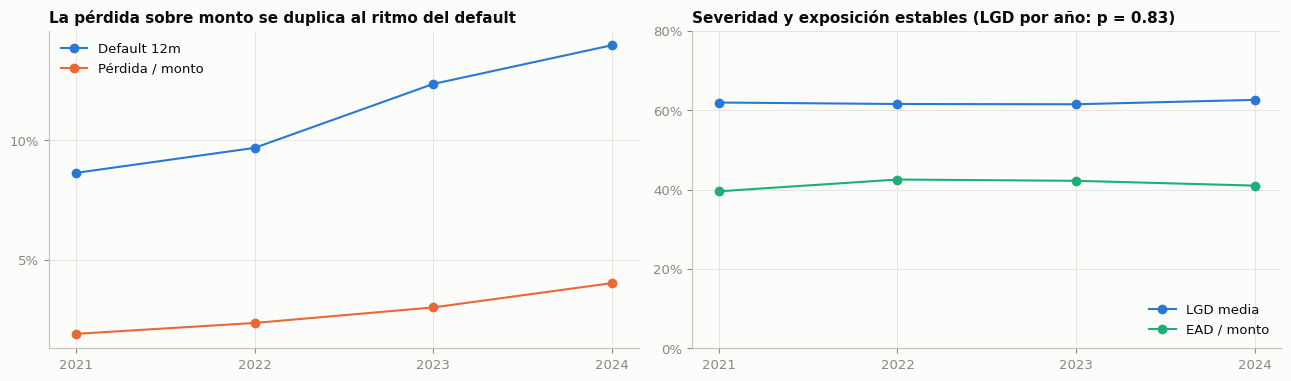

In [11]:
perdida = eda.loss_decomposition(dv)
display(perdida)
perdida.to_csv(cfg.TABLES / "eda_descomposicion_perdida.csv")
dd = dv[dv[T] == 1]
lgd_buro = dd.groupby(pd.qcut(dd["bureau_score"], 3, labels=["Buró bajo", "Buró medio", "Buró alto"]), observed=True)["lgd_observed"].agg(["size", "mean"])
p_lgd_anio = stats.kruskal(*[g["lgd_observed"] for _, g in dd.groupby(dd[cfg.DATE_COL].dt.year)]).pvalue
rho_lgd = stats.spearmanr(dd["bureau_score"], dd["lgd_observed"], nan_policy="omit")
display(lgd_buro)
print(f"LGD por año: Kruskal-Wallis p = {p_lgd_anio:.2f} | LGD vs buró: Spearman {rho_lgd.statistic:.2f} (p = {rho_lgd.pvalue:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.9))
anios = perdida.index.astype(str)
axes[0].plot(anios, perdida["default_rate"], marker="o", color=BLUE, label="Default 12m")
axes[0].plot(anios, perdida["perdida_sobre_monto"], marker="o", color=ORANGE, label="Pérdida / monto")
axes[0].set_title("La pérdida sobre monto se duplica al ritmo del default"); pct_axis(axes[0]); axes[0].legend()
axes[1].plot(anios, perdida["lgd_media"], marker="o", color=BLUE, label="LGD media")
axes[1].plot(anios, perdida["ead_sobre_monto_default"], marker="o", color=AQUA, label="EAD / monto")
axes[1].set_ylim(0, 0.8); pct_axis(axes[1]); axes[1].legend(loc="lower right")
axes[1].set_title(f"Severidad y exposición estables (LGD por año: p = {p_lgd_anio:.2f})")
fig.tight_layout(); savefig(fig, "fig17_descomposicion_perdida"); plt.show()

**Hallazgo 13 · La pérdida creció por frecuencia, no por severidad.** Entre 2021 y 2024 el default pasa de 8.6% a 14.0% y la pérdida sobre monto de 1.9% a 4.0%. En cambio, la LGD se mantiene entre 61.5% y 62.6% (sin diferencia entre años, p = 0.83) y la EAD entre 40% y 43% del monto. La LGD apenas cambia con el buró (de 63.5% a 60.1% entre terciles).
*Impacto:* la PD es la palanca de la Expected Loss. Para LGD basta un baseline segmentado simple (por banda de buró) contra el cual comparar el modelo de 6.11, y en el stress (6.12) el shock principal va a la PD, no a la LGD.

## 10. Mapa de segmentos y concentración de la pérdida

Participación en créditos y monto, default con IC y pérdida realizada sobre monto por segmento de negocio: dónde está el riesgo y dónde la exposición.

In [12]:
si_no = lambda s: s.map({True: "Sí", False: "No"})
capacidad = np.select([dev["dti_post"].isna(), dev["dti_post"] > cfg.DTI_POST_AUTO_MAX], ["Sin ingreso", "Sí"], "No")
mapa = eda.segment_map(dev, {
    "Canal": dev["channel"],
    "Región": dev["region"],
    "Cliente nuevo": si_no(dev["new_customer_flag"] == 1),
    "Efectivo > 80%": si_no(dev["cash_income_share"] > cfg.HIGH_CASH_SHARE),
    "Sin score de buró": si_no(dev["bureau_score"].isna()),
    "DTI post > 45%": pd.Series(capacidad, index=dev.index),
    "Monto > S/ 20,000": si_no(dev["requested_amount"] > cfg.MICRO_MAX_AUTO_AMOUNT),
})
display(mapa)
mapa.to_csv(cfg.TABLES / "eda_mapa_segmentos_dev.csv", index=False)

,segmentacion,segmento,creditos,pct_creditos,pct_monto,default_rate,ic_inf,ic_sup,perdida_sobre_monto
0,Canal,agencia,748,0.2173,0.2161,0.1163,0.0953,0.1413,0.0284
1,Canal,alianza,337,0.0979,0.0968,0.0890,0.0631,0.1242,0.0230
2,Canal,app,1144,0.3323,0.3364,0.0970,0.0812,0.1156,0.0246
3,Canal,web,1214,0.3526,0.3507,0.1013,0.0856,0.1196,0.0212
4,Región,Centro,529,0.1536,0.1527,0.0907,0.0691,0.1183,0.0218
5,Región,Lima,1420,0.4124,0.4112,0.1141,0.0986,0.1317,0.0251
6,Región,Norte,667,0.1937,0.1944,0.1079,0.0866,0.1338,0.0284
7,Región,Oriente,329,0.0956,0.0919,0.0942,0.0672,0.1306,0.0278
8,Región,Sur,498,0.1446,0.1498,0.0763,0.0561,0.1030,0.0159
9,Cliente nuevo,No,1893,0.5498,0.5459,0.0967,0.0842,0.1108,0.0235


DEV


,creditos,pct_creditos,default_rate,pct_defaults,pct_perdida,pct_perdida_acumulada
tramo,,,,,,
Q1 (bajo),676,0.1963,0.2189,0.4217,0.4036,0.4036
Q2,659,0.1914,0.1199,0.2251,0.2457,0.6493
Q3,664,0.1929,0.0813,0.1538,0.1428,0.7922
Q4,664,0.1929,0.0678,0.1282,0.1295,0.9217
Q5 (alto),654,0.1900,0.0291,0.0541,0.0643,0.9860
Faltante,126,0.0366,0.0476,0.0171,0.0140,1.0000


VAL


,creditos,pct_creditos,default_rate,pct_defaults,pct_perdida,pct_perdida_acumulada
tramo,,,,,,
Q1 (bajo),213,0.1851,0.2582,0.3416,0.3317,0.3317
Q2,209,0.1816,0.1818,0.2360,0.2547,0.5864
Q3,225,0.1955,0.1378,0.1925,0.2366,0.8230
Q4,247,0.2146,0.0972,0.1491,0.1145,0.9375
Q5 (alto),221,0.1920,0.0452,0.0621,0.0410,0.9784
Faltante,36,0.0313,0.0833,0.0186,0.0216,1.0000


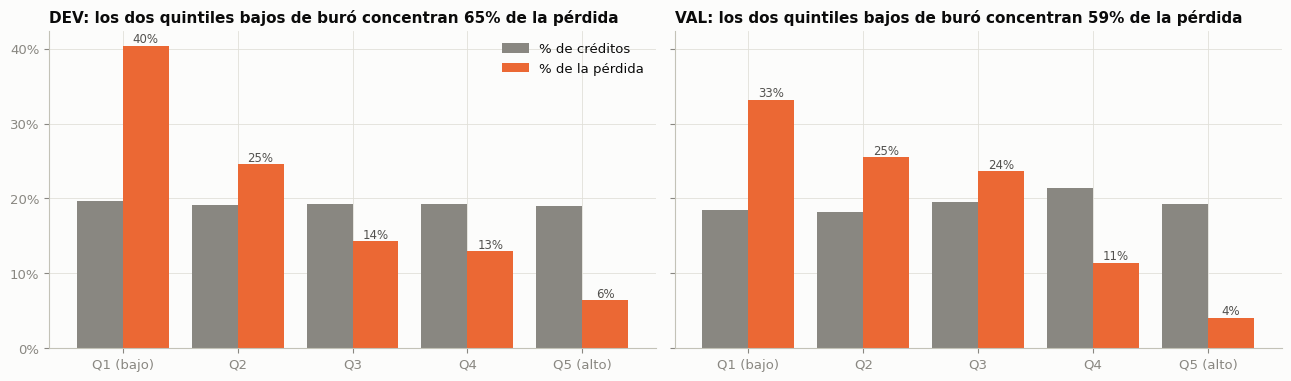

In [13]:
# ¿Dónde se concentra la pérdida? Quintiles de buró con los cortes de DEV, aplicados igual en VAL.
cortes_q5 = eda.quantile_edges(dev["bureau_score"], 5)
etq_q5 = ["Q1 (bajo)", "Q2", "Q3", "Q4", "Q5 (alto)"]
conc = {s: eda.loss_concentration(d, "bureau_score", cortes_q5, etq_q5) for s, d in muestras.items()}
for s, t in conc.items():
    print(s); display(t[["creditos", "pct_creditos", "default_rate", "pct_defaults", "pct_perdida", "pct_perdida_acumulada"]])
pd.concat(conc).to_csv(cfg.TABLES / "eda_concentracion_perdida_buro.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.9), sharey=True)
for ax, (s, t) in zip(axes, conc.items()):
    t = t.drop(index="Faltante", errors="ignore")
    x = np.arange(len(t))
    ax.bar(x - 0.2, t["pct_creditos"], width=0.4, color=MUTED, label="% de créditos")
    ax.bar(x + 0.2, t["pct_perdida"], width=0.4, color=ORANGE, label="% de la pérdida")
    for x_, v in zip(x, t["pct_perdida"]):
        ax.text(x_ + 0.2, v, f"{v:.0%}", ha="center", va="bottom", fontsize=8.5, color=INK_2)
    ax.set_xticks(x, t.index); pct_axis(ax); ax.set_title(f"{s}: los dos quintiles bajos de buró concentran {t['pct_perdida'].iloc[:2].sum():.0%} de la pérdida")
axes[0].legend(loc="upper right")
fig.tight_layout(); savefig(fig, "fig18_concentracion_perdida"); plt.show()


**Hallazgo 14 · La pérdida se concentra en los dos quintiles más bajos del buró.** En DEV, el quintil más bajo tiene el 20% de los créditos, pero el 42% de los defaults y el 40% de la pérdida realizada; los dos quintiles más bajos suman el 65% de la pérdida con el 39% de los créditos. VAL, con los mismos cortes, repite el patrón (59% de la pérdida en los dos quintiles bajos). El segmento sin score aporta apenas 1%-2% de la pérdida.
*Impacto:* es la base cuantitativa del punto de corte (6.9). La zona de rechazo y de revisión se define en los tramos bajos del score, donde cada punto de aprobación que se resigna ahorra más pérdida. Los segmentos de negocio del mapa (canal, región, efectivo) pesan mucho menos que el buró en dónde se pierde.


## 11. Hallazgos accionables

Cada fila resume evidencia, interpretación e impacto. Las cifras se leen de los objetos calculados arriba para que la tabla no se desincronice del análisis.

In [14]:
d10_dev = buro.drop(index="Faltante", errors="ignore")["dev_default_rate"]
c_dev, c_val = cap.drop(index="Faltante", errors="ignore")["dev_default_rate"], cap.drop(index="Faltante", errors="ignore")["val_default_rate"]
mora = historial.loc["prior_delinquencies_24m (0 / 1 / 2+)"]
caja_q = bloques["cash_income_share"].drop(index="Faltante", errors="ignore")
hallazgos = pd.DataFrame([
    (1, "Señal concentrada", f"{len(senal)} de {len(scr)} candidatas con q < 0.05 en DEV: {', '.join(senal)}",
     "La mayoría de variables son ruido en esta cartera", "Scorecard parsimonioso; no agregar variables sin señal"),
    (2, "Buró eje del riesgo y estable", f"Default {d10_dev.iloc[0]:.1%} (D1) a {d10_dev.iloc[-1]:.1%} (D10) en DEV; AUC anual {auc_anio.min():.2f}-{auc_anio.max():.2f}; AUC por canal {auc_canal.min():.2f}-{auc_canal.max():.2f}",
     "Ordena igual en el tiempo y en todos los canales", "Característica principal con tramos monótonos; sin scorecard por canal"),
    (3, "Deterioro de nivel, no de orden", f"+{lvl['cambio_log_odds']:.2f} log-odds en VAL (OR {lvl['odds_ratio_val']:.2f}, p < 0.001); cambio de pendiente p = {lvl['p_pendiente']:.2f}",
     "La curva de riesgo se desplazó en paralelo", "Recalibrar el intercepto con VAL (6.7); separar score y tabla score → PD"),
    (4, "Tendencia gradual", f"Odds x{coh_res['odds_ratio_anual']:.2f} por año (p < 0.001); escalón 2023 p = {coh_res['p_escalon_sobre_tendencia']:.2f}",
     "El nivel de PD envejece rápido", "Calibración con ventana reciente, disparador de recalibración y escenario Adverse con tendencia"),
    (5, "Umbral de capacidad en 45%", f"DEV: {c_dev.iloc[0]:.1%} / {c_dev.iloc[1]:.1%} hasta 45%, {c_dev.iloc[2]:.1%} en 45-60% y {c_dev.iloc[3]:.1%} en 60-80%; VAL repite el quiebre",
     "Relación no lineal con meseta hasta 45%", "Tramo sin penalidad hasta 45%; regla de capacidad 45% / 60%"),
    (6, "Buró y capacidad aditivos", f"De {np.nanmin(inter['default_rate'].to_numpy()):.1%} a {np.nanmax(inter['default_rate'].to_numpy()):.1%} en la matriz 3x3; interacción p = {inter['p_interaccion']:.2f}",
     "Los efectos se suman en log-odds", "Scorecard aditivo adecuado; matriz banda de score x capacidad"),
    (7, "Mora previa no se sostiene", f"DEV {mora['dev_default_rate'].iloc[0]:.1%} / {mora['dev_default_rate'].iloc[1]:.1%} / {mora['dev_default_rate'].iloc[2]:.1%}; VAL {mora['val_default_rate'].iloc[0]:.1%} / {mora['val_default_rate'].iloc[1]:.1%} / {mora['val_default_rate'].iloc[2]:.1%}",
     "Señal de DEV que se invierte en VAL", "Solo entra al scorecard si no se invierte en VAL (criterio S6 de 6.5)"),
    (8, "Canal digital sin mayor riesgo en DEV; web se aparta en 2024", f"Chi² DEV p = {p_canal['DEV']:.2f}; VAL p = {p_canal['VAL']:.2f} (web {canal.loc['web', 'val_default_rate']:.1%})",
     "Crecer fuera de agencias no deterioró DEV; alerta puntual en web", "Canal fuera del modelo; KRI de default por canal y revisión del flujo web"),
    (9, "Brecha creciente de clientes nuevos", "Brecha nuevos − antiguos: " + ", ".join(f"{a} {b:+.1f} pp" for a, b in nuevos["brecha_pp"].items()),
     "Riesgo emergente que DEV no captura", "Monitoreo por cohorte, límite de concentración y monto acotado del primer crédito"),
    (10, "Efectivo alto inestable", f"Quintil superior vs resto: DEV {caja_q['dev_default_rate'].iloc[-1]:.1%} vs {caja_q['dev_default_rate'].iloc[:-1].min():.1%}-{caja_q['dev_default_rate'].iloc[:-1].max():.1%}; VAL {caja_q['val_default_rate'].iloc[-1]:.1%} vs {caja_q['val_default_rate'].iloc[:-1].min():.1%}-{caja_q['val_default_rate'].iloc[:-1].max():.1%}",
     "Sin necesidad de negocio; proxy de informalidad", "Fuera del modelo; verificación de ingreso y AIR por efectivo"),
    (11, "Territorio, distancia, hogar y edad sin señal", f"Región DEV p = {p_region['DEV']:.2f}, VAL p = {p_region['VAL']:.2f}; ninguna pasa el tamizaje",
     "No hay justificación para usarlas", "Excluidas del scorecard por diseño; se usan en fairness (6.8)"),
    (12, "Monto y plazo no son PD; ticket grande inestable", f"AUC monto {p_monto[0]:.2f}, plazo {p_plazo[0]:.2f}; > S/ 20k: default DEV {concentracion.loc['DEV', 'default_gt_20k']:.1%} vs VAL {concentracion.loc['VAL', 'default_gt_20k']:.1%} ({concentracion.loc['VAL', 'creditos_gt_20k']} créditos), {concentracion.loc['VAL', 'pct_monto']:.0%} del monto y {concentracion.loc['VAL', 'pct_perdida']:.0%} de la pérdida de VAL",
     "Sin relación estable con la PD; exposición concentrada", "Monto por capacidad, límite de concentración y revisión obligatoria > S/ 20k; EL y stress en monto"),
    (13, "Pérdida por frecuencia", f"Default {perdida['default_rate'].iloc[0]:.1%} → {perdida['default_rate'].iloc[-1]:.1%}; LGD {perdida['lgd_media'].min():.1%}-{perdida['lgd_media'].max():.1%} (p = {p_lgd_anio:.2f})",
     "La severidad no explica el deterioro", "PD como palanca de EL; LGD con baseline segmentado; stress sobre PD"),
    (14, "Pérdida concentrada en buró bajo", f"DEV: Q1 {conc['DEV'].loc['Q1 (bajo)', 'pct_creditos']:.0%} de créditos y {conc['DEV'].loc['Q1 (bajo)', 'pct_perdida']:.0%} de la pérdida; Q1+Q2 {conc['DEV']['pct_perdida'].iloc[:2].sum():.0%} (VAL {conc['VAL']['pct_perdida'].iloc[:2].sum():.0%})",
     "Donde se pierde es en los tramos bajos del buró, no en segmentos de negocio", "Punto de corte y zona de revisión en los tramos bajos del score (6.9)"),
], columns=["n", "hallazgo", "evidencia", "interpretacion", "impacto_politica_modelo"])
with pd.option_context("display.max_colwidth", 120):
    display(hallazgos)
hallazgos.to_csv(cfg.TABLES / "eda_hallazgos.csv", index=False)

,n,hallazgo,evidencia,interpretacion,impacto_politica_modelo
0,1,Señal concentrada,"5 de 22 candidatas con q < 0.05 en DEV: bureau_score, dti, dti_post, prior_delinquencies_24m, monthly_debt_payment",La mayoría de variables son ruido en esta cartera,Scorecard parsimonioso; no agregar variables sin señal
1,2,Buró eje del riesgo y estable,Default 26.6% (D1) a 2.4% (D10) en DEV; AUC anual 0.67-0.71; AUC por canal 0.66-0.71,Ordena igual en el tiempo y en todos los canales,Característica principal con tramos monótonos; sin scorecard por canal
2,3,"Deterioro de nivel, no de orden","+0.42 log-odds en VAL (OR 1.52, p < 0.001); cambio de pendiente p = 0.49",La curva de riesgo se desplazó en paralelo,Recalibrar el intercepto con VAL (6.7); separar score y tabla score → PD
3,4,Tendencia gradual,Odds x1.20 por año (p < 0.001); escalón 2023 p = 0.38,El nivel de PD envejece rápido,"Calibración con ventana reciente, disparador de recalibración y escenario Adverse con tendencia"
4,5,Umbral de capacidad en 45%,"DEV: 8.6% / 8.0% hasta 45%, 11.2% en 45-60% y 15.5% en 60-80%; VAL repite el quiebre",Relación no lineal con meseta hasta 45%,Tramo sin penalidad hasta 45%; regla de capacidad 45% / 60%
5,6,Buró y capacidad aditivos,De 3.1% a 24.3% en la matriz 3x3; interacción p = 0.90,Los efectos se suman en log-odds,Scorecard aditivo adecuado; matriz banda de score x capacidad
6,7,Mora previa no se sostiene,DEV 8.8% / 11.7% / 12.8%; VAL 14.7% / 11.9% / 17.0%,Señal de DEV que se invierte en VAL,Solo entra al scorecard si no se invierte en VAL (criterio S6 de 6.5)
7,8,Canal digital sin mayor riesgo en DEV; web se aparta en 2024,Chi² DEV p = 0.46; VAL p = 0.04 (web 17.8%),Crecer fuera de agencias no deterioró DEV; alerta puntual en web,Canal fuera del modelo; KRI de default por canal y revisión del flujo web
8,9,Brecha creciente de clientes nuevos,"Brecha nuevos − antiguos: 2021 -0.5 pp, 2022 +0.6 pp, 2023 +3.4 pp, 2024 +4.7 pp",Riesgo emergente que DEV no captura,"Monitoreo por cohorte, límite de concentración y monto acotado del primer crédito"
9,10,Efectivo alto inestable,Quintil superior vs resto: DEV 11.8% vs 9.4%-10.4%; VAL 18.7% vs 10.4%-15.0%,Sin necesidad de negocio; proxy de informalidad,Fuera del modelo; verificación de ingreso y AIR por efectivo
